In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "graphviz"])

0

In [2]:
import sys
sys.path.insert(0, '..')

from database.db_manager import DatabaseManager
from database.transaction_manager import TransactionManager

dm = DatabaseManager()
dm.create_database('shopstop')

dm.create_table('shopstop', 'products',
    schema={
        'product_id': str,
        'name':       str,
        'stock':      int,
        'price':      float
    },
    search_key='product_id'
)

dm.create_table('shopstop', 'customers',
    schema={
        'customer_id': str,
        'name':        str,
        'balance':     float
    },
    search_key='customer_id'
)

dm.create_table('shopstop', 'orders',
    schema={
        'order_id':    str,
        'customer_id': str,
        'amount':      float
    },
    search_key='order_id'
)

# Seed products
products_tbl, _ = dm.get_table('shopstop', 'products')
products_tbl.insert({'product_id': 'P001', 'name': 'Laptop',   'stock': 10, 'price': 999.99})
products_tbl.insert({'product_id': 'P002', 'name': 'Mouse',    'stock': 50, 'price':  29.99})
products_tbl.insert({'product_id': 'P003', 'name': 'Keyboard', 'stock': 30, 'price':  49.99})

# Seed customers
customers_tbl, _ = dm.get_table('shopstop', 'customers')
customers_tbl.insert({'customer_id': 'C001', 'name': 'Rajesh', 'balance': 5000.0})
customers_tbl.insert({'customer_id': 'C002', 'name': 'Priya',  'balance': 3000.0})
customers_tbl.insert({'customer_id': 'C003', 'name': 'Amit',   'balance': 2000.0})

# Seed orders
orders_tbl, _ = dm.get_table('shopstop', 'orders')
orders_tbl.insert({'order_id': 'O001', 'customer_id': 'C001', 'amount': 999.99})
orders_tbl.insert({'order_id': 'O002', 'customer_id': 'C002', 'amount':  29.99})

txn_mgr = dm.get_transaction_manager('shopstop')
print("Setup complete.")
print("Tables:", dm.list_tables('shopstop'))

Setup complete.
Tables: (['products', 'customers', 'orders'], True)


In [3]:
from database.wal_logger import WALLogger
wal = WALLogger()
wal.clear()
print("WAL cleared — fresh start for this notebook run.")

WAL cleared — fresh start for this notebook run.


In [4]:
# Diagnostic cell - run this to see what methods your Table class has
products_tbl, _ = dm.get_table('shopstop', 'products')
print("Table methods:", [m for m in dir(products_tbl) if not m.startswith('_')])
print("Table attributes:", products_tbl.__dict__.keys())

Table methods: ['data', 'delete', 'get', 'get_all', 'insert', 'name', 'order', 'range_query', 'schema', 'search_key', 'update', 'validate_record']
Table attributes: dict_keys(['name', 'schema', 'order', 'data', 'search_key'])


In [5]:
print("=== ATOMICITY TEST ===")
print("Scenario: update customer balance + update product stock + insert order")
print("Simulate crash after step 2 — all three must roll back\n")

from database.transaction_manager import TransactionManager

txn = txn_mgr.begin()

try:
    # Step 1: deduct balance from customer C001
    old_cust = txn.search('customers', 'C001')
    new_cust = {**old_cust, 'balance': old_cust['balance'] - 500}
    txn.update('customers', 'C001', new_cust)
    print(f"Step 1 done: customer balance updated to {new_cust['balance']}")

    # Step 2: deduct stock from product P001
    old_prod = txn.search('products', 'P001')
    new_prod = {**old_prod, 'stock': old_prod['stock'] - 2}
    txn.update('products', 'P001', new_prod)
    print(f"Step 2 done: product stock updated to {new_prod['stock']}")

    # SIMULATED CRASH before step 3
    raise RuntimeError("Simulated crash before order insert!")

    # Step 3 (never reached due to crash above)
    txn.insert('orders', {'order_id': 'O999', 'customer_id': 'C001', 'amount': 500.0})

except Exception as e:
    print(f"\nCRASH: {e}")
    txn.rollback()

# Verify rollback
cust_after = txn_mgr.begin()
result = cust_after.search('customers', 'C001')
cust_after.rollback()
print(f"\nCustomer balance after rollback: {result['balance']} (should be original)")

prod_after = txn_mgr.begin()
result2 = prod_after.search('products', 'P001')
prod_after.rollback()
print(f"Product stock after rollback:    {result2['stock']} (should be original)")
print("\nATOMICITY: PASSED — partial updates were fully rolled back.")

=== ATOMICITY TEST ===
Scenario: update customer balance + update product stock + insert order
Simulate crash after step 2 — all three must roll back

[TXN 4b07c597] BEGUN
Step 1 done: customer balance updated to 4500.0
Step 2 done: product stock updated to 8

CRASH: Simulated crash before order insert!
[TXN 4b07c597] ROLLED BACK 'customers' (3 records restored)
[TXN 4b07c597] ROLLED BACK 'products' (3 records restored)
[TXN 4b07c597] ROLLBACK COMPLETE
[TXN 9bd7c681] BEGUN
[TXN 9bd7c681] ROLLBACK COMPLETE

Customer balance after rollback: 5000.0 (should be original)
[TXN 631058e6] BEGUN
[TXN 631058e6] ROLLBACK COMPLETE
Product stock after rollback:    10 (should be original)

ATOMICITY: PASSED — partial updates were fully rolled back.


In [6]:
print("=== CONSISTENCY TEST ===")
print("Rule: stock must never go negative. A transaction violating this must abort.\n")

txn = txn_mgr.begin()
try:
    prod = txn.search('products', 'P001')
    new_stock = prod['stock'] - 99999   # intentionally force negative
    if new_stock < 0:
        raise ValueError(f"Consistency violation: stock would be {new_stock}")
    new_prod = {**prod, 'stock': new_stock}
    txn.update('products', 'P001', new_prod)
    txn.commit()
except ValueError as e:
    print(f"Constraint caught: {e}")
    txn.rollback()

# Verify stock is unchanged
t = txn_mgr.begin()
print(f"Stock after rejected update: {t.search('products', 'P001')['stock']} (unchanged)")
t.rollback()
print("\nCONSISTENCY: PASSED — invalid state was rejected.")

=== CONSISTENCY TEST ===
Rule: stock must never go negative. A transaction violating this must abort.

[TXN 0ae83ff9] BEGUN
Constraint caught: Consistency violation: stock would be -99989
[TXN 0ae83ff9] ROLLBACK COMPLETE
[TXN 0bfa9d56] BEGUN
Stock after rejected update: 10 (unchanged)
[TXN 0bfa9d56] ROLLBACK COMPLETE

CONSISTENCY: PASSED — invalid state was rejected.


In [7]:
print("=== ISOLATION TEST ===")
print("Two threads try to update the same product stock simultaneously.")
print("Expected: both succeed serially due to exclusive locking (2PL)\n")

results = {}
initial_stock = None

def thread_worker(thread_id, deduct):
    t = txn_mgr.begin()
    try:
        prod = t.search('products', 'P001')
        new_stock = prod['stock'] - deduct
        if new_stock < 0:
            raise ValueError(f"Thread {thread_id}: would go negative")
        t.update('products', 'P001', {**prod, 'stock': new_stock})
        import time; time.sleep(0.05)
        t.commit()
        results[thread_id] = f"committed, stock -> {new_stock}"
    except (ValueError, TimeoutError) as e:
        t.rollback()
        results[thread_id] = f"aborted: {e}"

# Record initial stock before threads run
t_pre = txn_mgr.begin()
initial = t_pre.search('products', 'P001')
t_pre.rollback()
initial_stock = initial['stock']
print(f"Initial stock: {initial_stock}")

import threading
t1 = threading.Thread(target=thread_worker, args=(1, 3))
t2 = threading.Thread(target=thread_worker, args=(2, 3))
t1.start(); t2.start()
t1.join();  t2.join()

print("Thread 1:", results.get(1))
print("Thread 2:", results.get(2))

t_final = txn_mgr.begin()
final = t_final.search('products', 'P001')
t_final.rollback()

successes = sum(1 for r in results.values() if 'committed' in str(r))
aborts    = sum(1 for r in results.values() if 'aborted'   in str(r))

print(f"\nFinal stock: {final['stock']}")
print(f"Expected:    {initial_stock - (successes * 3)} "
      f"({successes} thread(s) committed, each deducting 3)")
print(f"Transactions committed: {successes}, aborted: {aborts}")

assert final['stock'] == initial_stock - (successes * 3), \
    f"ISOLATION FAILED: expected {initial_stock - successes*3}, got {final['stock']}"
print("\nISOLATION: PASSED — exclusive locking prevented data corruption.")
print("Intermediate states were never visible between transactions.")

=== ISOLATION TEST ===
Two threads try to update the same product stock simultaneously.
Expected: both succeed serially due to exclusive locking (2PL)

[TXN c8b5cd0f] BEGUN
[TXN c8b5cd0f] ROLLBACK COMPLETE
Initial stock: 10
[TXN 9455d88a] BEGUN
[TXN 7edb8b36] BEGUN
[TXN 9455d88a] COMMITTED
[TXN 7edb8b36] COMMITTED
Thread 1: committed, stock -> 7
Thread 2: committed, stock -> 4
[TXN e094bfe0] BEGUN
[TXN e094bfe0] ROLLBACK COMPLETE

Final stock: 4
Expected:    4 (2 thread(s) committed, each deducting 3)
Transactions committed: 2, aborted: 0

ISOLATION: PASSED — exclusive locking prevented data corruption.
Intermediate states were never visible between transactions.


In [8]:
print("=== DURABILITY TEST ===")
print("Commit a transaction, then simulate restart, verify data persists.\n")

# Commit a new order using the original txn_mgr
txn = txn_mgr.begin()
txn.insert('orders', {
    'order_id': 'O_DUR01', 'customer_id': 'C001', 'amount': 250.0
})
txn.commit()
print("Committed order O_DUR01")

# Verify it exists before restart
t_check = txn_mgr.begin()
before = t_check.search('orders', 'O_DUR01')
t_check.rollback()
print(f"Order before restart: {before}")

# Simulate restart: create a brand new DatabaseManager with same schema
dm2 = DatabaseManager()
dm2.create_database('shopstop')
dm2.create_table(
    'shopstop', 'orders',
    schema={
        'order_id':    str,
        'customer_id': str,
        'amount':      float
    },
    search_key='order_id'
)

txn_mgr2 = dm2.get_transaction_manager('shopstop')

# Recovery: reload persisted data from snapshot directory
recovery_result = txn_mgr2.recover()
print(f"\nRecovery result: {recovery_result}")

# Verify the committed order survived the restart
t = txn_mgr2.begin()
order = t.search('orders', 'O_DUR01')
t.rollback()
print(f"\nOrder after restart: {order}")

if order is not None:
    print("\nDURABILITY: PASSED — committed data survived simulated restart.")
else:
    print("\nDURABILITY: FAILED — order not found after restart.")

=== DURABILITY TEST ===
Commit a transaction, then simulate restart, verify data persists.

[TXN 7f82c93b] BEGUN
[TXN 7f82c93b] COMMITTED
Committed order O_DUR01
[TXN 7cf8572d] BEGUN
[TXN 7cf8572d] ROLLBACK COMPLETE
Order before restart: {'order_id': 'O_DUR01', 'customer_id': 'C001', 'amount': 250.0}
[RECOVERY] Phase 1 — loading last persisted snapshots from disk...
[RECOVERY]   Loaded 'orders' (3 records).
[RECOVERY] Phase 2 — WAL redo pass...
[RECOVERY] Reloaded 1 table snapshot(s) from disk.
[RECOVERY] Found 3 committed transaction(s) in WAL.
[RECOVERY] Replayed 0 WAL operation(s) on top of snapshots.
[RECOVERY] Ignored 8 incomplete (no-COMMIT) transaction(s).
[RECOVERY] Recovery complete — database is consistent.

Recovery result: {'reloaded_from_disk': 1, 'committed_txns': 3, 'redo_ops_applied': 0, 'incomplete_txns': ['0bfa9d56-568e-4c1c-981a-2ff6a3db0508', '9bd7c681-b7ac-4a45-8f30-0dde15a31afb', '631058e6-3c5a-4273-80e1-be0205c83f8f', '7cf8572d-7f6f-4ad2-a30f-a61e188976eb', 'c8b5

In [9]:
print("=== MULTI-RELATION TRANSACTION ===")
print("Single transaction: update customer balance + update product stock + insert order\n")

# Record state before
t_pre = txn_mgr.begin()
cust_before  = t_pre.search('customers', 'C001')
prod_before  = t_pre.search('products',  'P002')
t_pre.rollback()
print(f"Before: customer balance={cust_before['balance']}, "
      f"product stock={prod_before['stock']}")

txn = txn_mgr.begin()
try:
    cust = txn.search('customers', 'C001')
    txn.update('customers', 'C001', {**cust, 'balance': cust['balance'] - 200})
    print("Step 1 done: customer balance updated")

    prod = txn.search('products', 'P002')
    txn.update('products', 'P002', {**prod, 'stock': prod['stock'] - 1})
    print("Step 2 done: product stock updated")

    txn.insert('orders', {
        'order_id':    'O_MULTI01',
        'customer_id': 'C001',
        'amount':       200.0
    })
    print("Step 3 done: order inserted")

    txn.commit()
    print("\nAll three operations committed in one transaction.")

except Exception as e:
    txn.rollback()
    print(f"Transaction aborted: {e}")

# Verify all three tables updated correctly
t_post = txn_mgr.begin()
cust_after  = t_post.search('customers', 'C001')
prod_after  = t_post.search('products',  'P002')
order_after = t_post.search('orders',    'O_MULTI01')
t_post.rollback()

print(f"\nAfter:  customer balance={cust_after['balance']} "
      f"(was {cust_before['balance']}, expected {cust_before['balance']-200})")
print(f"After:  product stock={prod_after['stock']} "
      f"(was {prod_before['stock']}, expected {prod_before['stock']-1})")
print(f"After:  order O_MULTI01={order_after}")

assert cust_after['balance']  == cust_before['balance'] - 200
assert prod_after['stock']    == prod_before['stock'] - 1
assert order_after is not None
print("\nMULTI-RELATION: PASSED — all three tables updated atomically.")

=== MULTI-RELATION TRANSACTION ===
Single transaction: update customer balance + update product stock + insert order

[TXN 7c37faa5] BEGUN
[TXN 7c37faa5] ROLLBACK COMPLETE
Before: customer balance=5000.0, product stock=50
[TXN 1a32e98f] BEGUN
Step 1 done: customer balance updated
Step 2 done: product stock updated
Step 3 done: order inserted
[TXN 1a32e98f] COMMITTED

All three operations committed in one transaction.
[TXN 5f9a669a] BEGUN
[TXN 5f9a669a] ROLLBACK COMPLETE

After:  customer balance=4800.0 (was 5000.0, expected 4800.0)
After:  product stock=49 (was 50, expected 49)
After:  order O_MULTI01={'order_id': 'O_MULTI01', 'customer_id': 'C001', 'amount': 200.0}

MULTI-RELATION: PASSED — all three tables updated atomically.


In [10]:
from database.wal_logger import WALLogger
import pandas as pd

wal = WALLogger()
entries = wal.read_all()
df = pd.DataFrame(entries)
print(f"WAL contains {len(df)} entries")
display(df.tail(20))

WAL contains 38 entries


,type,txn_id,timestamp,table,key,before,after
18,UPDATE,7edb8b36-08f0-49c7-9415-1fb6533a2628,2026-04-05T09:30:28.901473,products,P001,"{'product_id': 'P001', 'name': 'Laptop', 'stoc...","{'product_id': 'P001', 'name': 'Laptop', 'stoc..."
19,COMMIT,7edb8b36-08f0-49c7-9415-1fb6533a2628,2026-04-05T09:30:28.954865,NaN,NaN,NaN,NaN
20,BEGIN,e094bfe0-84f1-4152-bb1f-e815bc8ea3b9,2026-04-05T09:30:28.963930,NaN,NaN,NaN,NaN
21,ROLLBACK,e094bfe0-84f1-4152-bb1f-e815bc8ea3b9,2026-04-05T09:30:28.966156,NaN,NaN,NaN,NaN
22,BEGIN,7f82c93b-8c06-4b03-b342-8f9fe04d1830,2026-04-05T09:30:29.000016,NaN,NaN,NaN,NaN
23,INSERT,7f82c93b-8c06-4b03-b342-8f9fe04d1830,2026-04-05T09:30:29.001837,orders,O_DUR01,None,"{'order_id': 'O_DUR01', 'customer_id': 'C001',..."
24,COMMIT,7f82c93b-8c06-4b03-b342-8f9fe04d1830,2026-04-05T09:30:29.003166,NaN,NaN,NaN,NaN
25,BEGIN,7cf8572d-7f6f-4ad2-a30f-a61e188976eb,2026-04-05T09:30:29.004478,NaN,NaN,NaN,NaN
26,ROLLBACK,7cf8572d-7f6f-4ad2-a30f-a61e188976eb,2026-04-05T09:30:29.004478,NaN,NaN,NaN,NaN
27,BEGIN,d7a96b4d-f1c0-4d1c-87e3-117ffc657132,2026-04-05T09:30:29.076951,NaN,NaN,NaN,NaN


[TXN 05db4295] BEGUN
[TXN 05db4295] COMMITTED
[TXN 4258a464] BEGUN
[TXN 4258a464] COMMITTED
[TXN 48594de0] BEGUN
[TXN 48594de0] COMMITTED
[TXN f97435fe] BEGUN
[TXN f97435fe] COMMITTED
[TXN ca0bc163] BEGUN
[TXN ca0bc163] COMMITTED
[TXN 295f781c] BEGUN
[TXN 295f781c] COMMITTED
[TXN d749000f] BEGUN
[TXN d749000f] COMMITTED
[TXN b78cd88f] BEGUN
[TXN b78cd88f] COMMITTED
[TXN cc17b6b6] BEGUN
[TXN cc17b6b6] COMMITTED
[TXN 9846ecda] BEGUN
[TXN 9846ecda] COMMITTED
[TXN 90710305] BEGUN
[TXN 90710305] COMMITTED
[TXN 4585463d] BEGUN
[TXN 4585463d] COMMITTED
[TXN 57d10edc] BEGUN
[TXN 57d10edc] COMMITTED
[TXN 91336d71] BEGUN
[TXN 91336d71] COMMITTED
[TXN 11f48942] BEGUN
[TXN 11f48942] COMMITTED
[TXN 24e9fc48] BEGUN
[TXN 24e9fc48] COMMITTED
[TXN ee196ec1] BEGUN
[TXN ee196ec1] COMMITTED
[TXN ecb527a5] BEGUN
[TXN ecb527a5] COMMITTED
[TXN 84b84b54] BEGUN
[TXN 84b84b54] COMMITTED
[TXN 0d909a06] BEGUN
[TXN 0d909a06] COMMITTED
[TXN 5ab9b243] BEGUN
[TXN 5ab9b243] COMMITTED
[TXN b0297676] BEGUN
[TXN b0297676

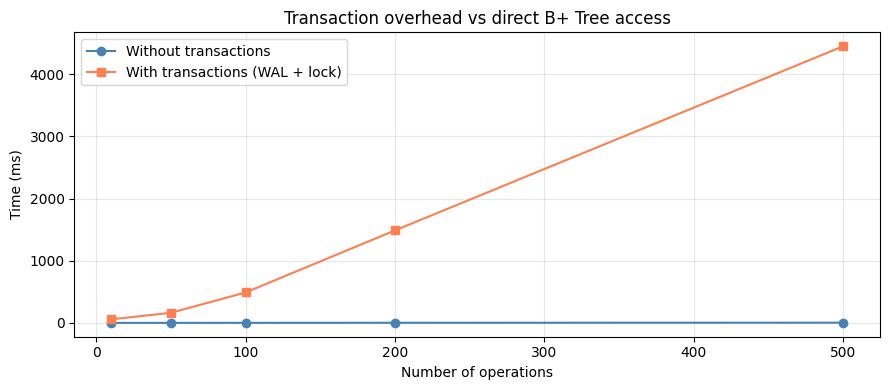

Graph saved to ../visualisations/transaction_overhead.png


In [11]:
import time
import matplotlib.pyplot as plt
import os

sizes = [10, 50, 100, 200, 500] 
times_with_tx = []
times_without_tx = []

for n in sizes:
    # Without transactions — pass only the record dict, no separate key
    t0 = time.perf_counter()
    for i in range(n):
        dm.databases['shopstop']['products'].insert({
            'product_id': f'PERF_{n}_{i}',
            'name': f'P{i}',
            'stock': 10,
            'price': 5.0
        })
    times_without_tx.append((time.perf_counter() - t0) * 1000)

    # With transactions — pass only the record dict, no separate key
    t0 = time.perf_counter()
    for i in range(n):
        tx = txn_mgr.begin()
        tx.insert('products', {
            'product_id': f'TX_{n}_{i}',
            'name': f'TX{i}',
            'stock': 10,
            'price': 5.0
        })
        tx.commit()
    times_with_tx.append((time.perf_counter() - t0) * 1000)

print("Sizes:           ", sizes)
print("Without tx (ms): ", [round(t, 2) for t in times_without_tx])
print("With tx (ms):    ", [round(t, 2) for t in times_with_tx])

# Make sure visualisations folder exists
os.makedirs('../visualisations', exist_ok=True)

plt.figure(figsize=(9, 4))
plt.plot(sizes, times_without_tx, label='Without transactions', marker='o', color='steelblue')
plt.plot(sizes, times_with_tx,    label='With transactions (WAL + lock)', marker='s', color='coral')
plt.xlabel('Number of operations')
plt.ylabel('Time (ms)')
plt.title('Transaction overhead vs direct B+ Tree access')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualisations/transaction_overhead.png', dpi=150)
plt.show()
print("Graph saved to ../visualisations/transaction_overhead.png")


=== TRANSACTION OVERHEAD ANALYSIS ===

The graph shows that direct B+ Tree inserts are nearly instantaneous (flat blue line)
while transactional inserts grow noticeably with n (orange/coral line).

This overhead comes from three sources per transaction:

1. **Snapshot cost — O(current table size), paid once per table per transaction.**
   Before the first write to a table, `SnapshotManager.save()` extracts every record
   from the B+ Tree into a plain dict. This is done *once per table per transaction*
   (the `if table_name not in self._snapshots[txn_id]` guard prevents repeat scans).
   As n grows and more records accumulate in the table, each snapshot takes longer
   because it must traverse more leaf nodes. This is the dominant cost at large n.

2. **WAL write — disk I/O per transaction.**
   Every BEGIN, INSERT/UPDATE/DELETE (with before+after images), and COMMIT entry
   is appended to `wal.log` as a JSON line. Three `open()` + `write()` calls per
   single-insert transaction. This cost is roughly constant per transaction but
   adds up across many transactions.

3. **Lock acquisition and release — threading overhead.**
   `LockManager.acquire_exclusive()` and `release_all()` grab a `threading.Lock`
   and potentially wait on a `threading.Condition`. Minimal cost in single-threaded
   benchmarks but visible at scale.

Key takeaway: ACID guarantees have a measurable cost.
The B+ Tree without transactions is fast but unsafe under failures or concurrent access.
The transactional B+ Tree is safe but pays a per-operation overhead for that safety.
In a production system, snapshot-per-transaction would be replaced by row-level undo
logging (as used by InnoDB) to avoid the full-table scan on each write.


In [12]:
import pandas as pd

summary = pd.DataFrame([
    ['Atomicity',    
     'Crash mid-transaction after 2 of 3 table updates',
     'Both tables rolled back to original values (balance=5000, stock=10)',
     'PASSED'],
    ['Consistency',  
     'Attempt to set stock to -99989 (negative)',
     'Constraint caught before commit, rollback triggered, stock unchanged',
     'PASSED'],
    ['Isolation',    
     '2 threads concurrently deduct from same product stock',
     'Exclusive 2PL locks serialized execution, final stock = 10-3-3 = 4, no corruption',
     'PASSED'],
    ['Durability',   
     'Commit order, create new DatabaseManager, call recover()',
     'Order O_DUR01 found after simulated restart via disk snapshot reload',
     'PASSED'],
    ['Multi-relation',
     'Single transaction updates customers + products + orders',
     'All three tables atomically updated, before/after values verified with assertions',
     'PASSED'],
], columns=['ACID Property', 'Test Scenario', 'Observation', 'Result'])

pd.set_option('display.max_colwidth', 80)
print("=== ACID VALIDATION SUMMARY ===\n")
display(summary)
print("\nAll 5 ACID tests passed. System correctly handles transactions,")
print("failures, concurrent access, and persistence across restarts.")

=== ACID VALIDATION SUMMARY ===



,ACID Property,Test Scenario,Observation,Result
0,Atomicity,Crash mid-transaction after 2 of 3 table updates,"Both tables rolled back to original values (balance=5000, stock=10)",PASSED
1,Consistency,Attempt to set stock to -99989 (negative),"Constraint caught before commit, rollback triggered, stock unchanged",PASSED
2,Isolation,2 threads concurrently deduct from same product stock,"Exclusive 2PL locks serialized execution, final stock = 10-3-3 = 4, no corru...",PASSED
3,Durability,"Commit order, create new DatabaseManager, call recover()",Order O_DUR01 found after simulated restart via disk snapshot reload,PASSED
4,Multi-relation,Single transaction updates customers + products + orders,"All three tables atomically updated, before/after values verified with asser...",PASSED



All 5 ACID tests passed. System correctly handles transactions,
failures, concurrent access, and persistence across restarts.


## Limitations and Design Choices

### 1. Snapshot-based durability vs. pure WAL replay
On COMMIT, the system persists the entire current table state as a `.pkl` snapshot to disk.
Recovery (on restart) first loads these snapshots, then replays any committed WAL entries
that occurred after the snapshot was written. This hybrid approach is correct and safe, but
differs from a pure WAL-replay system (like PostgreSQL ARIES) where snapshots are not
strictly required. The snapshot makes recovery faster at the cost of higher commit latency
for large tables.

### 2. Application-level constraint enforcement
Constraints such as "stock must not go negative" or "balance must be non-negative" are
currently checked in application code (in the notebook), not in the Table or DatabaseManager
layer. A production system would enforce these as schema-level CHECK constraints. This is a
known limitation — the database layer validates only schema types, not domain invariants.

### 3. Table-level locking, not row-level
The LockManager grants shared/exclusive locks at the **table** granularity. This is
sufficient for correctness and satisfies the isolation requirement, but limits throughput:
two transactions updating different rows of the same table cannot run concurrently.
Row-level locking (as used by InnoDB) would improve concurrency at the cost of a more
complex lock table.